# Daily Summary — проверка данных


In [1]:
import polars as pl
from pathlib import Path

SUMMARIES_DIR = Path('../../data/daily_summaries')

files = sorted(SUMMARIES_DIR.glob('day_summary_*.parquet'))
print(f'Файлов найдено: {len(files)}')
print(f'Первый: {files[0].name}')
print(f'Последний: {files[-1].name}')

Файлов найдено: 61
Первый: day_summary_2024_03_01.parquet
Последний: day_summary_2024_04_30.parquet


In [2]:
df = pl.read_parquet(SUMMARIES_DIR / '*.parquet')
print(f'Строк: {len(df)}')
print(f'Период: {df["date"].min()} → {df["date"].max()}')
print(f'Уникальных дней: {df["date"].n_unique()}')
print(f'Уникальных категорий: {df["category"].n_unique()}')
df.schema

Строк: 37245
Период: 2024-03-01 → 2024-04-30
Уникальных дней: 61
Уникальных категорий: 611


Schema([('date', Date),
        ('category', String),
        ('n_users', UInt32),
        ('n_sessions', UInt32),
        ('rate_events', Float64),
        ('rate_searches', Float64),
        ('rate_views', Float64),
        ('rate_clicks', Float64),
        ('rate_carts', Float64),
        ('rate_favs', Float64),
        ('rate_unique_queries', Float64),
        ('is_cart', Int32)])

## Пример данных

In [3]:
df.sort('date').head(20)

date,category,n_users,n_sessions,rate_events,rate_searches,rate_views,rate_clicks,rate_carts,rate_favs,rate_unique_queries,is_cart
date,str,u32,u32,f64,f64,f64,f64,f64,f64,f64,i32
2024-03-01,"""1 ступень кормления""",456,473,26.02537,1.818182,22.58351,0.932347,0.672304,0.019027,1.665962,193
2024-03-01,"""180-240 л""",12,12,9.416667,1.666667,6.083333,0.583333,1.083333,0.0,1.583333,7
2024-03-01,"""2 ступень кормления""",169,175,9.8,1.377143,7.382857,0.508571,0.531429,0.0,1.325714,77
2024-03-01,"""3 ступень кормления""",200,204,12.04902,1.495098,9.406863,0.465686,0.666667,0.014706,1.421569,106
2024-03-01,"""4 ступень кормления""",100,102,11.323529,1.705882,8.186275,0.588235,0.833333,0.009804,1.588235,66
…,…,…,…,…,…,…,…,…,…,…,…
2024-03-01,"""Аксессуары для путешествий""",179,185,20.578378,2.07027,17.632432,0.735135,0.12973,0.010811,1.832432,16
2024-03-01,"""Аксессуары для пылесосов""",73,73,40.246575,2.69863,36.082192,0.917808,0.547945,0.0,2.273973,7
2024-03-01,"""Аксессуары для телевизоров""",282,293,29.877133,2.385666,26.361775,0.808874,0.286689,0.03413,2.030717,52


## Проверка полноты: нет ли пропущенных дней

In [4]:
from datetime import timedelta

all_dates = sorted(df['date'].unique().to_list())
missing = []
for a, b in zip(all_dates, all_dates[1:]):
    if (b - a).days > 1:
        missing.append((a, b))

if missing:
    print('Пропущенные промежутки:')
    for a, b in missing:
        print(f'  {a} → {b} (gap {(b-a).days}d)')
else:
    print('Пропущенных дней нет')

Пропущенных дней нет


## Проверка на null

In [5]:
null_counts = df.null_count()
print(null_counts)

shape: (1, 12)
┌──────┬──────────┬─────────┬────────────┬───┬────────────┬───────────┬──────────────────┬─────────┐
│ date ┆ category ┆ n_users ┆ n_sessions ┆ … ┆ rate_carts ┆ rate_favs ┆ rate_unique_quer ┆ is_cart │
│ ---  ┆ ---      ┆ ---     ┆ ---        ┆   ┆ ---        ┆ ---       ┆ ies              ┆ ---     │
│ u32  ┆ u32      ┆ u32     ┆ u32        ┆   ┆ u32        ┆ u32       ┆ ---              ┆ u32     │
│      ┆          ┆         ┆            ┆   ┆            ┆           ┆ u32              ┆         │
╞══════╪══════════╪═════════╪════════════╪═══╪════════════╪═══════════╪══════════════════╪═════════╡
│ 0    ┆ 0        ┆ 0       ┆ 0          ┆ … ┆ 0          ┆ 0         ┆ 0                ┆ 0       │
└──────┴──────────┴─────────┴────────────┴───┴────────────┴───────────┴──────────────────┴─────────┘


## Категории: распределение сессий

In [6]:
cat_summary = (
    df.group_by('category')
      .agg([
          pl.col('n_sessions').sum().alias('total_sessions'),
          pl.col('n_users').sum().alias('total_users'),
          pl.len().alias('n_days'),
      ])
      .sort('total_sessions', descending=True)
)
print(cat_summary)

shape: (611, 4)
┌────────────────────────────────┬────────────────┬─────────────┬────────┐
│ category                       ┆ total_sessions ┆ total_users ┆ n_days │
│ ---                            ┆ ---            ┆ ---         ┆ ---    │
│ str                            ┆ u32            ┆ u32         ┆ u32    │
╞════════════════════════════════╪════════════════╪═════════════╪════════╡
│ other                          ┆ 494189         ┆ 486213      ┆ 61     │
│ Сухие корма                    ┆ 168254         ┆ 162563      ┆ 61     │
│ Спортивные батончики и печенье ┆ 162027         ┆ 155802      ┆ 61     │
│ Густой йогурт                  ┆ 152244         ┆ 149639      ┆ 61     │
│ Подгузники-трусики             ┆ 151357         ┆ 144668      ┆ 61     │
│ …                              ┆ …              ┆ …           ┆ …      │
│ Нарезанные фрукты              ┆ 547            ┆ 541         ┆ 61     │
│ Теплый свет                    ┆ 535            ┆ 528         ┆ 61     │
│ Блины, 

## Динамика n_sessions по дням (all categories)

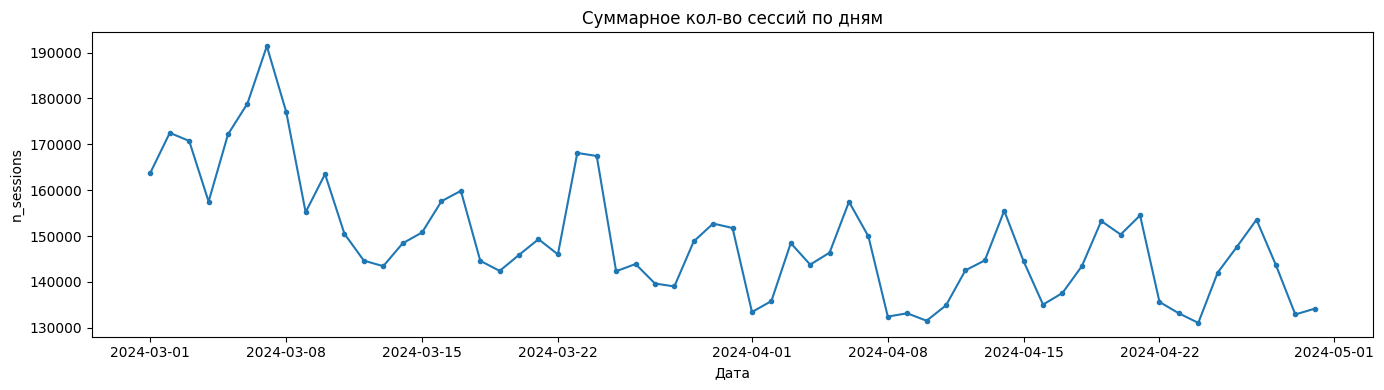

In [7]:
import matplotlib.pyplot as plt

daily_total = (
    df.group_by('date')
      .agg(pl.col('n_sessions').sum())
      .sort('date')
)

dates = daily_total['date'].to_list()
sessions = daily_total['n_sessions'].to_list()

plt.figure(figsize=(14, 4))
plt.plot(dates, sessions, marker='o', markersize=3)
plt.title('Суммарное кол-во сессий по дням')
plt.xlabel('Дата')
plt.ylabel('n_sessions')
plt.tight_layout()
plt.show()

## Динамика rate_unique_queries по категориям

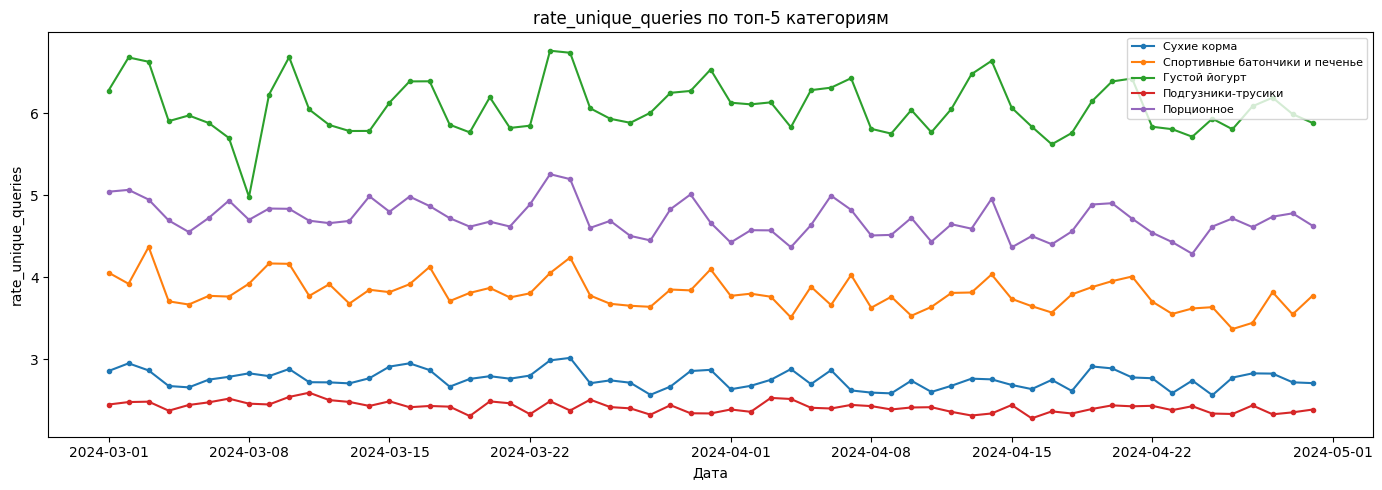

In [8]:
top_cats = cat_summary.filter(pl.col('category') != 'other').head(5)['category'].to_list()

plt.figure(figsize=(14, 5))
for cat in top_cats:
    subset = df.filter(pl.col('category') == cat).sort('date')
    plt.plot(subset['date'].to_list(), subset['rate_unique_queries'].to_list(), label=cat, marker='.')

plt.title('rate_unique_queries по топ-5 категориям')
plt.xlabel('Дата')
plt.ylabel('rate_unique_queries')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Статистика по метрикам

In [9]:
metric_cols = ['n_users', 'n_sessions', 'is_cart',
               'rate_events', 'rate_searches', 'rate_views',
               'rate_clicks', 'rate_carts', 'rate_favs', 'rate_unique_queries']

df.select(metric_cols).describe()

statistic,n_users,n_sessions,is_cart,rate_events,rate_searches,rate_views,rate_clicks,rate_carts,rate_favs,rate_unique_queries
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",37245.0,37245.0,37245.0,37245.0,37245.0,37245.0,37245.0,37245.0,37245.0,37245.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",239.729145,244.385985,117.101114,33.389375,2.603461,28.760419,0.926842,1.06525,0.033402,2.385436
"""std""",495.596912,506.705392,239.146968,66.558601,3.797824,61.238986,1.124461,1.049846,0.096264,2.347902
"""min""",1.0,1.0,0.0,1.758042,1.0,0.146235,0.0,0.0,0.0,1.0
"""25%""",32.0,33.0,7.0,14.191176,1.869565,11.142857,0.547872,0.290323,0.0,1.698413
"""50%""",94.0,96.0,28.0,25.230769,2.34,21.281853,0.831099,0.69697,0.023321,2.116402
"""75%""",245.0,248.0,102.0,43.848039,2.956989,38.413953,1.211921,1.567568,0.046296,2.736111
"""max""",20450.0,20891.0,4104.0,4991.73578,317.816514,4570.251376,84.218349,12.148624,7.300917,184.227523
